# GramSathi AI

# Notebook 06: Machine Learning Models

---

## Objective

This notebook develops and evaluates Machine Learning models that predict the infrastructure priority of villages.

The models use infrastructure indicators such as roads, schools, hospitals, buildings, bus stops, and water facilities to classify village development priority.

The best-performing model will later be integrated into the AI Recommendation Engine.

In [15]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [16]:
# ==========================================
# Generate Training Dataset
# ==========================================

np.random.seed(42)

n = 500

data = pd.DataFrame({

    "Road_Length_km": np.random.uniform(1,15,n),

    "School_Count": np.random.randint(0,5,n),

    "Hospital_Count": np.random.randint(0,3,n),

    "Bus_Stop_Count": np.random.randint(0,8,n),

    "Building_Count": np.random.randint(50,1500,n),

    "Water_Count": np.random.randint(0,6,n)

})

data.head()

,Road_Length_km,School_Count,Hospital_Count,Bus_Stop_Count,Building_Count,Water_Count
0,6.243562,0,2,2,1352,1
1,14.310000,0,1,0,900,1
2,11.247915,0,2,1,1438,4
3,9.381219,4,1,3,1404,3
4,3.184261,3,2,5,1417,3


# Generate Infrastructure Priority

A rule-based scoring system is initially used to create labels for training.

These labels represent infrastructure development priority and will be used as the target variable for supervised learning.

In [17]:
# ==========================================
# Create Target Variable
# ==========================================

score = (

0.30*data["Road_Length_km"]

+

0.15*data["School_Count"]

+

0.20*data["Hospital_Count"]

+

0.10*data["Bus_Stop_Count"]

+

0.15*(data["Building_Count"]/100)

+

0.10*data["Water_Count"]

)

data["Priority"] = np.where(

score<5,

"Critical",

np.where(

score<8,

"Needs Improvement",

"Developed"

)

)

data.head()

,Road_Length_km,School_Count,Hospital_Count,Bus_Stop_Count,Building_Count,Water_Count,Priority
0,6.243562,0,2,2,1352,1,Critical
1,14.310000,0,1,0,900,1,Needs Improvement
2,11.247915,0,2,1,1438,4,Needs Improvement
3,9.381219,4,1,3,1404,3,Needs Improvement
4,3.184261,3,2,5,1417,3,Critical


In [19]:
# ==========================================
# Class Distribution
# ==========================================

data["Priority"].value_counts()

Priority
Critical             293
Needs Improvement    206
Developed              1
Name: count, dtype: int64

In [20]:
# ==========================================
# Split Features
# ==========================================

X = data.drop("Priority",axis=1)

y = data["Priority"]

X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42

)

print("Training Samples :",len(X_train))

print("Testing Samples :",len(X_test))

Training Samples : 400
Testing Samples : 100


# Decision Tree Classifier

The Decision Tree algorithm is a supervised machine learning model that classifies villages into different infrastructure priority categories.

It creates decision rules based on infrastructure features such as roads, schools, hospitals, bus stops, buildings, and water facilities.

In [21]:
# ==========================================
# Decision Tree Model
# ==========================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy :", round(dt_accuracy*100,2),"%")

Decision Tree Accuracy : 88.0 %


# Random Forest Classifier

Random Forest is an ensemble learning algorithm.

It combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It is widely used in real-world decision support systems.

In [22]:
# ==========================================
# Random Forest Model
# ==========================================

rf_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy :", round(rf_accuracy*100,2),"%")

Random Forest Accuracy : 92.0 %


In [23]:
# ==========================================
# Accuracy Comparison
# ==========================================

comparison = pd.DataFrame({

    "Model":[

        "Decision Tree",

        "Random Forest"

    ],

    "Accuracy":[

        dt_accuracy*100,

        rf_accuracy*100

    ]

})

comparison

,Model,Accuracy
0,Decision Tree,88.0
1,Random Forest,92.0


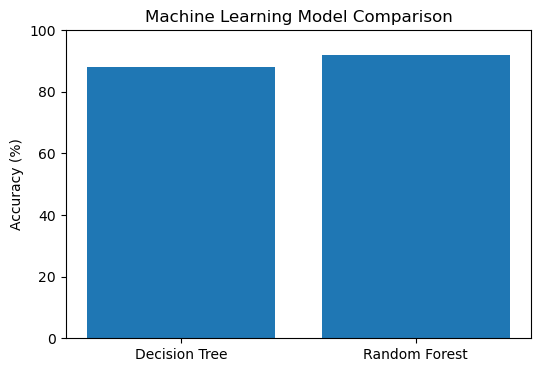

In [24]:
# ==========================================
# Accuracy Plot
# ==========================================

plt.figure(figsize=(6,4))

plt.bar(

    comparison["Model"],

    comparison["Accuracy"]

)

plt.title("Machine Learning Model Comparison")

plt.ylabel("Accuracy (%)")

plt.ylim(0,100)

plt.show()

# Best Model Selection

The model with the highest prediction accuracy is selected for deployment in the GramSathi AI Recommendation Engine.

In [25]:
# ==========================================
# Select Best Model
# ==========================================

if rf_accuracy > dt_accuracy:

    best_model = rf_model

    print("✅ Best Model : Random Forest")

else:

    best_model = dt_model

    print("✅ Best Model : Decision Tree")

✅ Best Model : Random Forest


In [26]:
# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
0,Road_Length_km,0.690211
4,Building_Count,0.159441
1,School_Count,0.048501
3,Bus_Stop_Count,0.042639
5,Water_Count,0.038677
2,Hospital_Count,0.020532


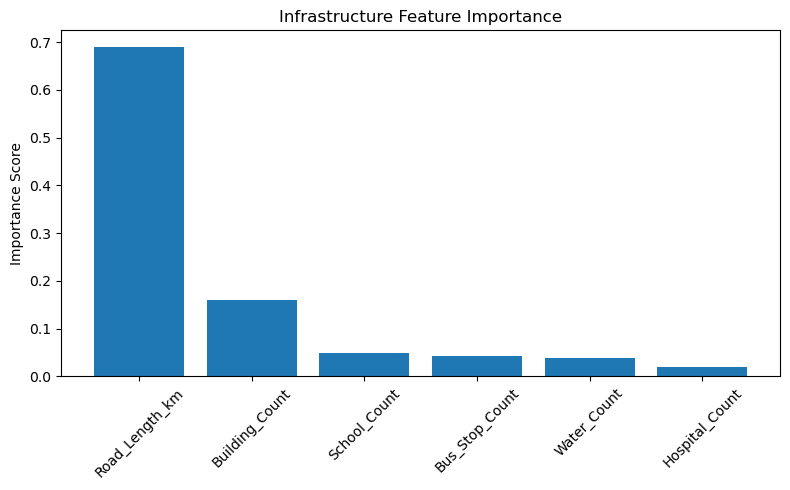

In [27]:
# ==========================================
# Feature Importance Plot
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(

    importance["Feature"],

    importance["Importance"]

)

plt.xticks(rotation=45)

plt.title("Infrastructure Feature Importance")

plt.ylabel("Importance Score")

plt.tight_layout()

plt.show()

In [28]:
# ==========================================
# Save Model
# ==========================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/gramsathi_ml_model.pkl")

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [29]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/random_forest_model.pkl")

print("✅ Random Forest Model Saved Successfully")

✅ Random Forest Model Saved Successfully
